# ***Lab 04. Morphological filtering***

1. Dùng camera chụp ảnh nền gạch, có gạch nứt/vỡ

2. Dùng phuơng phap binarize theo gobal threshold để phan đoạn ảnh -> Anh J2

3. Dung dilation and eoion ap dung hco anh J2 voi kích thuoc cua so neighborhood la 5x5., 2 ảnh rieng

4. Sử dụng các bộ lọc dựa trên kết hợp dilation và erosion để điều chỉnh sao cho thấy rõ các vết nứt/vỡ trên gạch nhất.

5. Sử dụng các bộ lọc kết hợp dilation và erosion để điều chỉnh sao cho ko còn thấy vết nứt vỡ (ảnh J5)

6. Đếm số lượng ô gạch xuất hiện trong ảnh J5

7. Quay lại ảnh gốc. Chuyển về dạng grayscale. Thêm 10% nhiễu salt and pepper. Hãy lọc nhiễu bằng bộ lọc median (cai đặt thủ công, ko dùng co sẵn)

In [10]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

def show_images(panels, figsize=None):
    if figsize is None:
        figsize = (5 * len(panels), 5)

    fig, axes = plt.subplots(1, len(panels), figsize=figsize)
    if len(panels) == 1:
        axes = [axes]

    for ax, (subtitle, image) in zip(axes, panels):
        ax.set_title(subtitle)
        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(image)
        ax.axis("off")

    plt.tight_layout()
    plt.show()



## 1. Dùng camera chụp ảnh nền gạch, có gạch nứt/vỡ

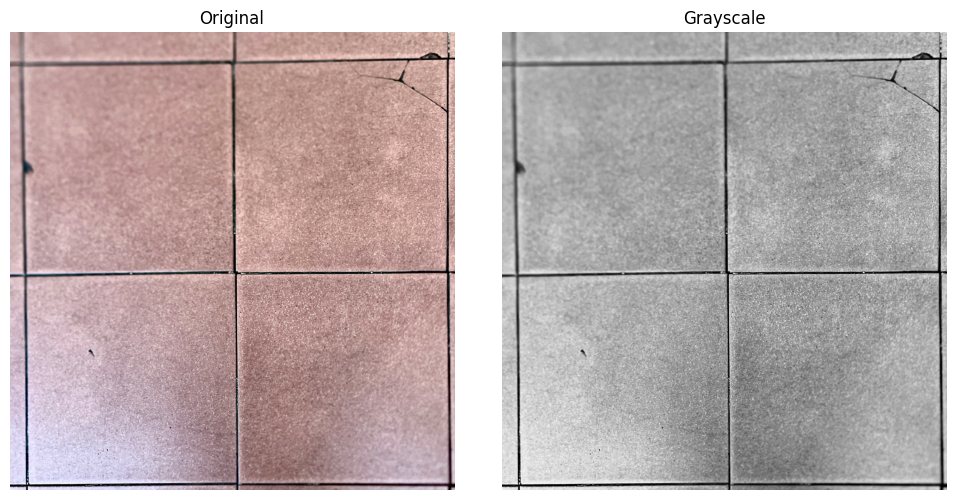

In [11]:
image_path = Path("image.jpg")
original_bgr = cv2.imread(str(image_path))
if original_bgr is None:
    raise FileNotFoundError(f"Cannot load {image_path}")

original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
original_gray = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2GRAY)

show_images([("Original", original_rgb), ("Grayscale", original_gray)])

## 2. Dùng phương pháp binarize theo gobal threshold để phân đoạn ảnh -> Ảnh J2

Global threshold value: 136


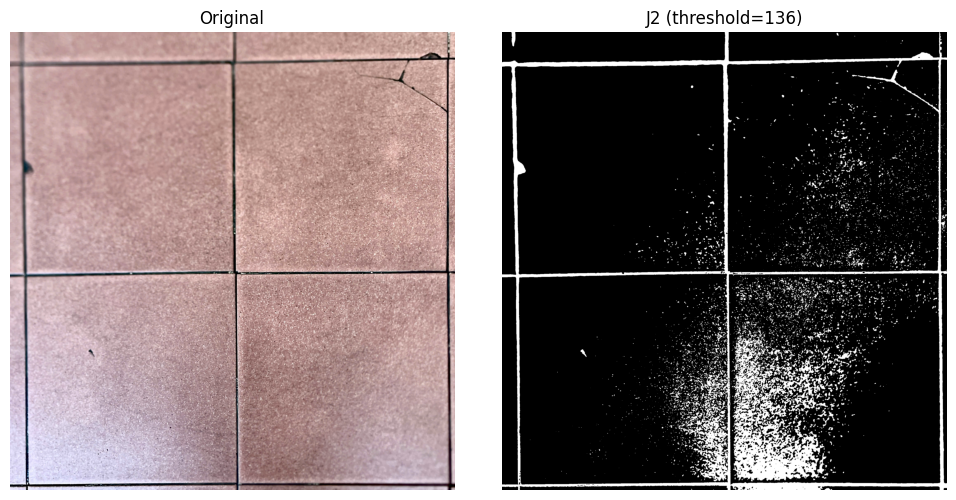

In [ ]:
threshold_value, j2 = cv2.threshold(original_gray, 0, 255, cv2.THRESH_BINARY_INV)
print(f"Global threshold value: {threshold_value:.0f}")
show_images(
    [("Original", original_rgb), (f"J2 (threshold={threshold_value:.0f})", j2)],
    figsize=(10, 5),
)

## 3. Dùng dilation and éoion áp dụng hco ảnh J2 với kích thước cửa sổ neighborhood là 5x5., 2 ảnh riêng

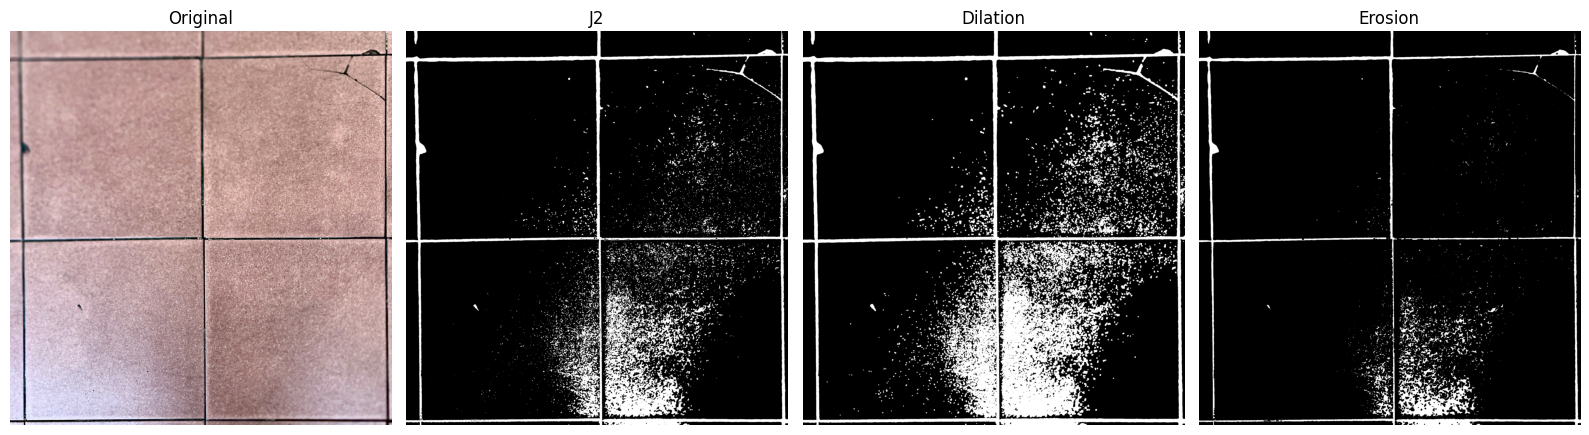

In [13]:
kernel5 = np.ones((5, 5), np.uint8)

j3_dilate = cv2.dilate(j2, kernel5, iterations=1)
j3_erode = cv2.erode(j2, kernel5, iterations=1)

show_images(
    [("Original", original_rgb), ("J2", j2), ("Dilation", j3_dilate), ("Erosion", j3_erode)],
    figsize=(16, 5),
)

## 4. Sử dụng các bộ lọc dựa trên kết hợp dilation và erosion để điều chỉnh sao cho thấy rõ các vết nứt/vỡ trên gạch nhất.

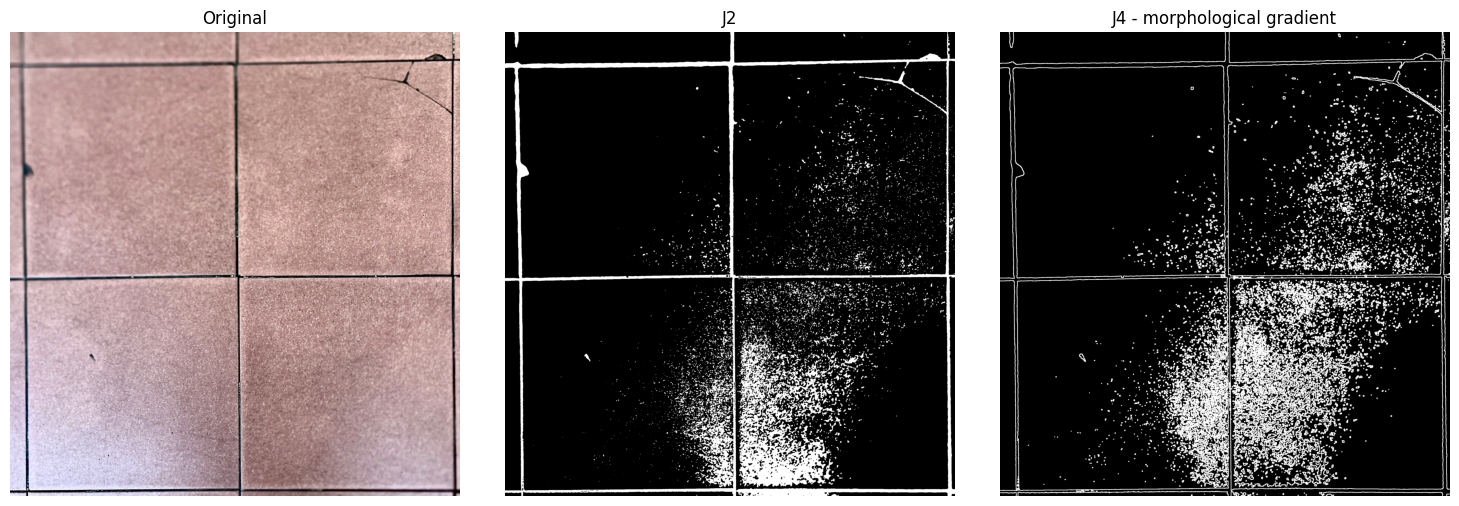

In [14]:
j4 = cv2.morphologyEx(j2, cv2.MORPH_GRADIENT, kernel5)

show_images(
    [("Original", original_rgb), ("J2", j2), ("J4 - morphological gradient", j4)],
    figsize=(15, 5),
)

## 5. Sử dụng các bộ lọc kết hợp dilation và erosion để điều chỉnh sao cho ko còn thấy vết nứt vỡ (ảnh J5)

## 6. Đếm số lượng ô gạch xuất hiện trong ảnh J5

## 7. Quay lại ảnh gốc. Chuyển về dạng grayscale. Thêm 10% nhiễu salt and pepper. Hãy lọc nhiễu bằng bộ lọc median (cài đặt thủ công, ko dùng có sẵn)

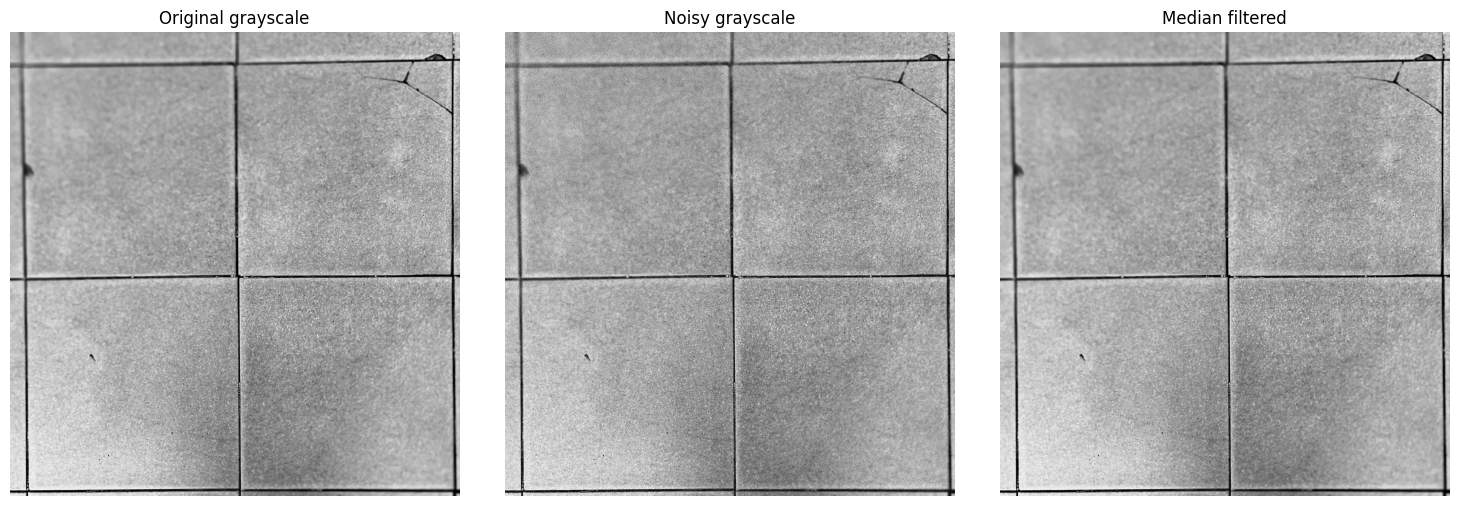

In [15]:
rng = np.random.default_rng(42)

sp_gray = original_gray.copy()
num_pixels = sp_gray.size
num_noisy = int(num_pixels * 0.10)
indices = rng.choice(num_pixels, size=num_noisy, replace=False)
half = num_noisy // 2
flat = sp_gray.reshape(-1)
flat[indices[:half]] = 0
flat[indices[half:]] = 255
noisy_gray = flat.reshape(sp_gray.shape)


def median_filter_manual(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad_width=pad, mode="edge")
    filtered = np.empty_like(image)

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            window = padded[row : row + kernel_size, col : col + kernel_size]
            filtered[row, col] = np.median(window)

    return filtered.astype(np.uint8)

filtered_gray = median_filter_manual(noisy_gray, kernel_size=3)

show_images(
    [("Original grayscale", original_gray), ("Noisy grayscale", noisy_gray), ("Median filtered", filtered_gray)],
    figsize=(15, 5),
)